1.Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. Load Dataset

In [ ]:
# Download the Airbnb listings dataset
!wget -O listings.csv.gz https://data.insideairbnb.com/united-states/ca/san-francisco/2025-09-01/data/listings.csv.gz

# Import pandas
import pandas as pd

# Read the dataset into a DataFrame
df = pd.read_csv("listings.csv.gz")

# Show the first 5 rows
df.head()

--2026-03-15 22:27:34--  https://data.insideairbnb.com/united-states/ca/san-francisco/2025-09-01/data/listings.csv.gz
Resolving data.insideairbnb.com (data.insideairbnb.com)... 52.85.78.89, 52.85.78.56, 52.85.78.60, ...
Connecting to data.insideairbnb.com (data.insideairbnb.com)|52.85.78.89|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4222281 (4.0M) [application/x-gzip]
Saving to: ‘listings.csv.gz’

listings.csv.gz     100%[===================>]   4.03M  22.1MB/s    in 0.2s    

2026-03-15 22:27:35 (22.1 MB/s) - ‘listings.csv.gz’ saved [4222281/4222281]



,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,958,https://www.airbnb.com/rooms/958,20250901181253,2025-09-01,city scrape,"Bright, Modern Garden Unit - 1BR/1BTH",Our bright garden unit overlooks a lovely back...,Quiet cul de sac in friendly neighborhood<br /...,https://a0.muscache.com/pictures/be1bf5ac-a955...,1169,...,4.89,4.98,4.78,STR-0006854,f,1,1,0,0,2.53
1,5858,https://www.airbnb.com/rooms/5858,20250901181253,2025-09-01,city scrape,Creative Sanctuary,We live in a large Victorian house on a quiet ...,I love how our neighborhood feels quiet but is...,https://a0.muscache.com/pictures/hosting/Hosti...,8904,...,4.85,4.77,4.68,NaN,f,1,1,0,0,0.53
2,8014,https://www.airbnb.com/rooms/8014,20250901181253,2025-09-01,city scrape,female HOST quiet fast internet market parking,Room is on the second floor so it gets a good ...,"The neighborhood is very residential, close to...",https://a0.muscache.com/pictures/2cc1fc3d-0ae0...,22402,...,4.94,4.59,4.66,STR-0000974,f,3,0,3,0,0.57
3,8142,https://www.airbnb.com/rooms/8142,20250901181253,2025-09-01,city scrape,*FriendlyRoom Apt. Style -UCSF/USF - San Franc...,Nice and good public transportation. 7 minute...,"N Juda Muni, Bus and UCSF Shuttle.<br /><br />...",https://a0.muscache.com/pictures/hosting/Hosti...,21994,...,4.80,4.70,4.70,NaN,f,20,0,20,0,0.07
4,8339,https://www.airbnb.com/rooms/8339,20250901181253,2025-09-01,city scrape,Historic Alamo Square Victorian,"For creative humans who love art, space, photo...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,24215,...,5.00,4.94,4.75,STR-0000264,f,1,1,0,0,0.13


3. Basic Dataset Information

In [ ]:
# Show the number of rows and columns
df.shape

# Show all column names
df.columns

# Show data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7780 entries, 0 to 7779
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            7780 non-null   int64  
 1   listing_url                                   7780 non-null   object 
 2   scrape_id                                     7780 non-null   int64  
 3   last_scraped                                  7780 non-null   object 
 4   source                                        7780 non-null   object 
 5   name                                          7780 non-null   object 
 6   description                                   7688 non-null   object 
 7   neighborhood_overview                         4683 non-null   object 
 8   picture_url                                   7780 non-null   object 
 9   host_id                                       7780 non-null   i

4. Select variables used in the analysis

In [ ]:
# Keep only the variables used in the analysis
df = df[[
    "price",
    "room_type",
    "neighbourhood_cleansed",
    "number_of_reviews",
    "review_scores_rating",
    "availability_365"
]]

# Show the new shape of the dataset
print(df.shape)

(7780, 6)


5. Data Cleaning

In [ ]:
# convert price
df["price"] = df["price"].replace(r"[\$,]", "", regex=True)
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# remove missing
df = df.dropna(subset=["price"])

# remove zero price
df = df[df["price"] > 0]

# remove outliers
upper = df["price"].quantile(0.99)
df = df[df["price"] <= upper]

# log transformation
df["log_price"] = np.log(df["price"])


In [ ]:
df.shape
df.head()
df.describe()

,price,number_of_reviews,review_scores_rating,availability_365,log_price
count,5737.000000,5737.000000,4609.000000,5737.000000,5737.000000
mean,230.348091,64.490500,4.804396,223.271571,5.166217
std,201.657373,125.450156,0.356121,111.979411,0.719653
min,29.000000,0.000000,1.000000,0.000000,3.367296
25%,104.000000,1.000000,4.770000,134.000000,4.644391
50%,169.000000,11.000000,4.910000,245.000000,5.129899
75%,280.000000,67.000000,5.000000,324.000000,5.634790
max,1614.000000,1417.000000,5.000000,365.000000,7.386471


In [ ]:
df.shape

(5737, 7)

Price Distribution

Mean price: 230.35
Median price: 169.0
Skewness of price: 2.69


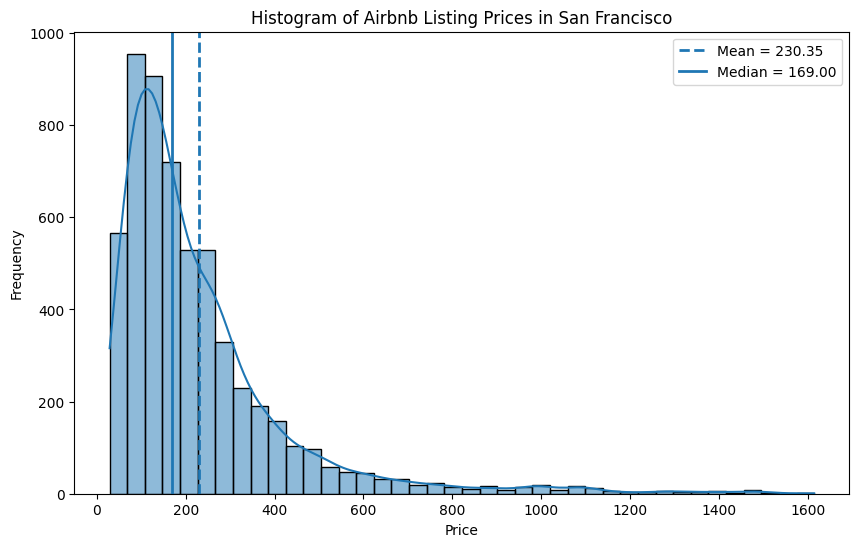

In [ ]:
# calculate statistics
price_mean = df["price"].mean()
price_median = df["price"].median()
price_skew = df["price"].skew()

print("Mean price:", round(price_mean, 2))
print("Median price:", round(price_median, 2))
print("Skewness of price:", round(price_skew, 2))

# create a histogram
plt.figure(figsize=(10, 6))
sns.histplot(df["price"], bins=40, kde=True)

# add vertical lines to indicate the mean and median values
plt.axvline(price_mean, linestyle="--", linewidth=2, label=f"Mean = {price_mean:.2f}")
plt.axvline(price_median, linestyle="-", linewidth=2, label=f"Median = {price_median:.2f}")

plt.title("Histogram of Airbnb Listing Prices in San Francisco")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.legend()
plt.show()

Room type vs Price

Average price by room type:
room_type
Entire home/apt    281.129664
Hotel room         242.730159
Private room       133.703588
Shared room         72.884615
Name: price, dtype: float64


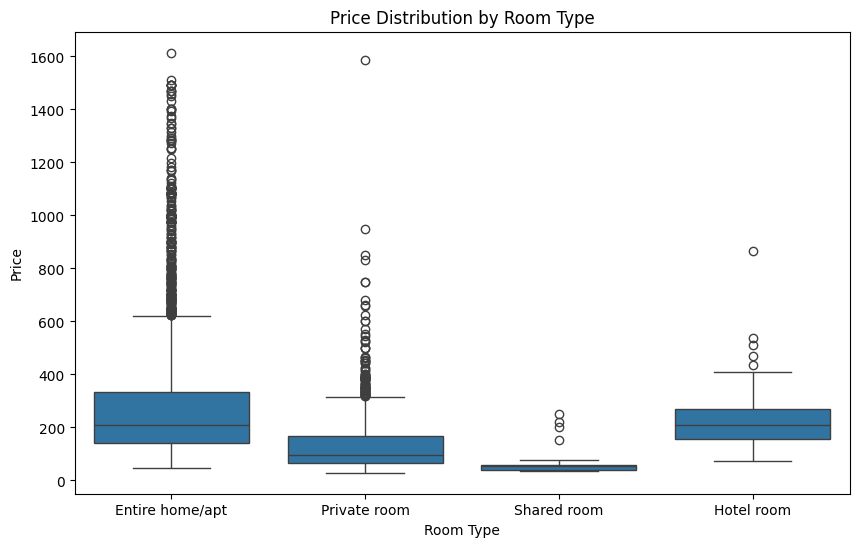

In [ ]:
# calculate average price by room type
room_price_mean = df.groupby("room_type")["price"].mean()
print("Average price by room type:")
print(room_price_mean)

# create a box plot
plt.figure(figsize=(10,6))
sns.boxplot(x="room_type", y="price", data=df)

plt.title("Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price")

plt.show()

Box plots for neiborhoods

Average price by neighbourhood:
neighbourhood_cleansed
North Beach            407.843931
Financial District     381.436242
Russian Hill           344.708029
Presidio               315.111111
Pacific Heights        312.272727
Diamond Heights        297.200000
Castro/Upper Market    290.112554
Presidio Heights       283.964286
Twin Peaks             276.875000
Noe Valley             275.288889
Name: price, dtype: float64


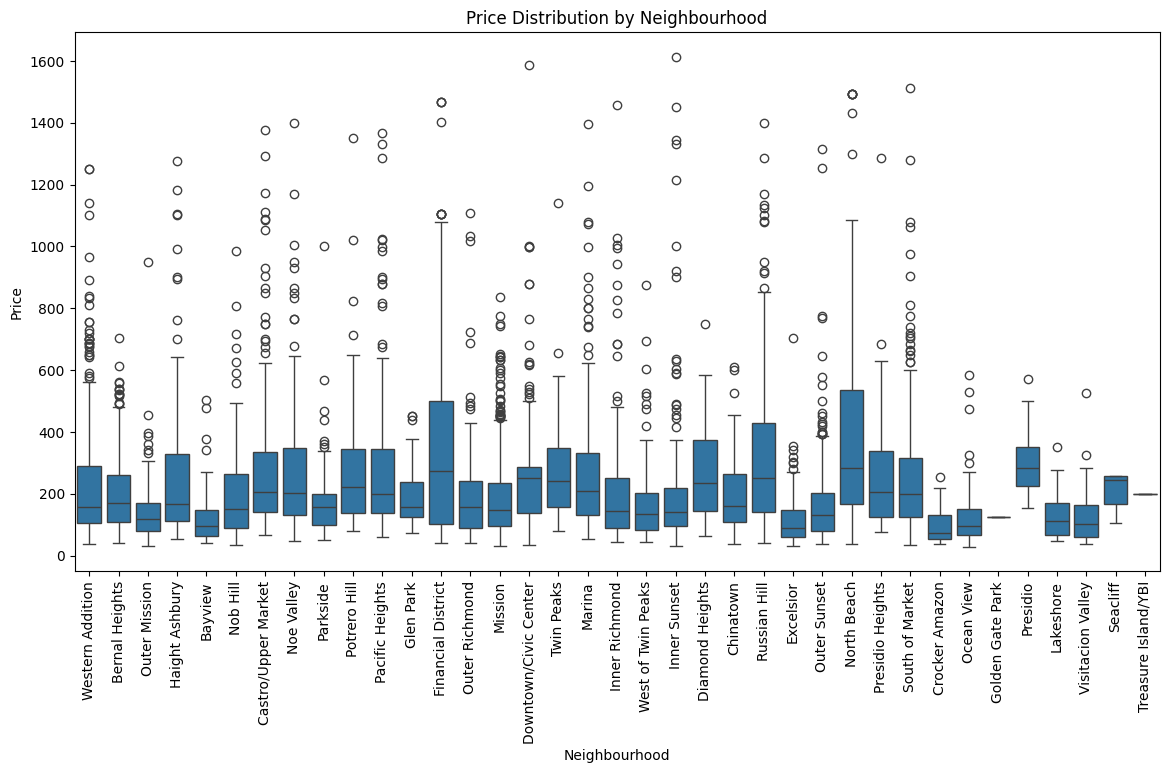

In [ ]:
# calculate average price by neighbourhood
neighbour_price_mean = df.groupby("neighbourhood_cleansed")["price"].mean().sort_values(ascending=False)
print("Average price by neighbourhood:")
print(neighbour_price_mean.head(10))

# box plot
plt.figure(figsize=(14,7))
sns.boxplot(x="neighbourhood_cleansed", y="price", data=df)

plt.xticks(rotation=90)
plt.title("Price Distribution by Neighbourhood")
plt.xlabel("Neighbourhood")
plt.ylabel("Price")

plt.show()

scatter plot

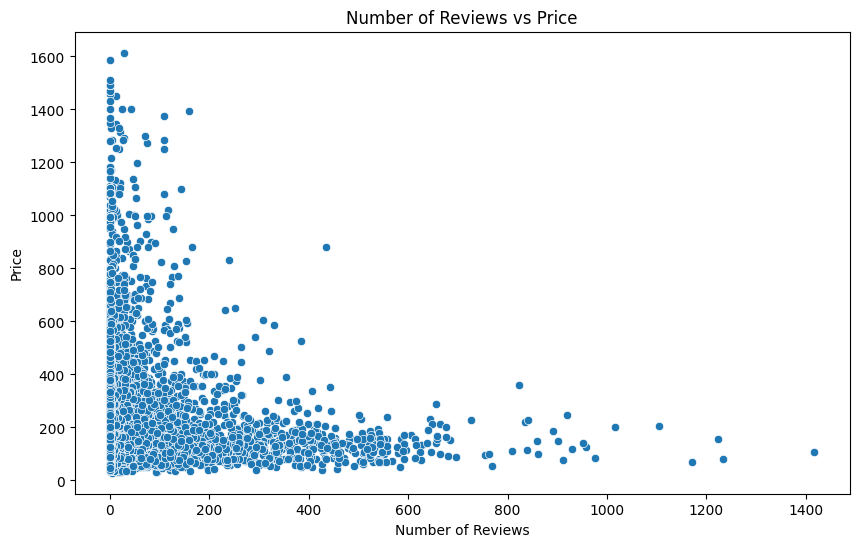

In [ ]:
# number of reviews vs price
plt.figure(figsize=(10,6))
sns.scatterplot(x="number_of_reviews", y="price", data=df)

plt.title("Number of Reviews vs Price")
plt.xlabel("Number of Reviews")
plt.ylabel("Price")

plt.show()


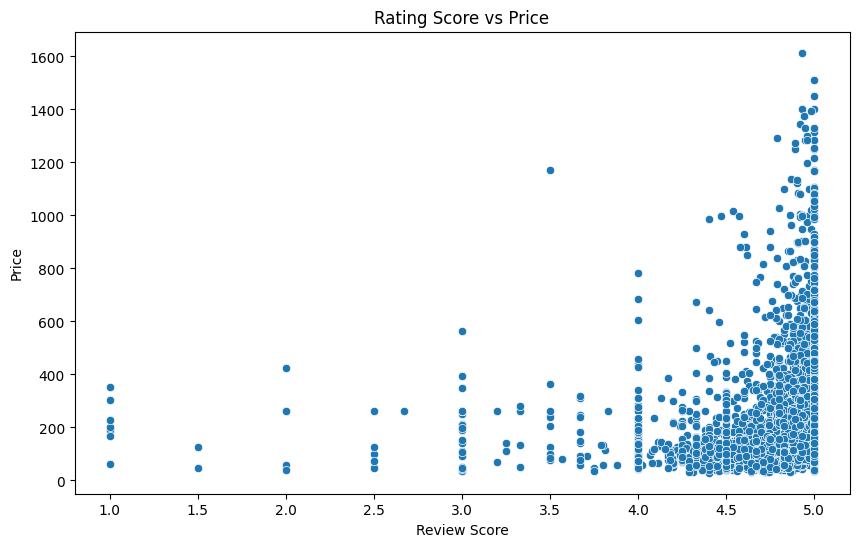

In [ ]:
# rating score vs price
plt.figure(figsize=(10,6))
sns.scatterplot(x="review_scores_rating", y="price", data=df)

plt.title("Rating Score vs Price")
plt.xlabel("Review Score")
plt.ylabel("Price")

plt.show()

regression model

In [ ]:
import statsmodels.formula.api as smf

# Model 1: log(price) ~ room_type
model1 = smf.ols("log_price ~ C(room_type)", data=df).fit()

print("Model 1: log(price) ~ room_type")
print(model1.summary())


# Model 2: full model with multiple variables
model2 = smf.ols(
    "log_price ~ C(room_type) + C(neighbourhood_cleansed) + number_of_reviews + review_scores_rating + availability_365",
    data=df
).fit()

print("\nModel 2: Full Model")
print(model2.summary())

Model 1: log(price) ~ room_type
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.246
Model:                            OLS   Adj. R-squared:                  0.245
Method:                 Least Squares   F-statistic:                     622.7
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        22:23:24   Log-Likelihood:                -5443.5
No. Observations:                5737   AIC:                         1.090e+04
Df Residuals:                    5733   BIC:                         1.092e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

Residual Plot

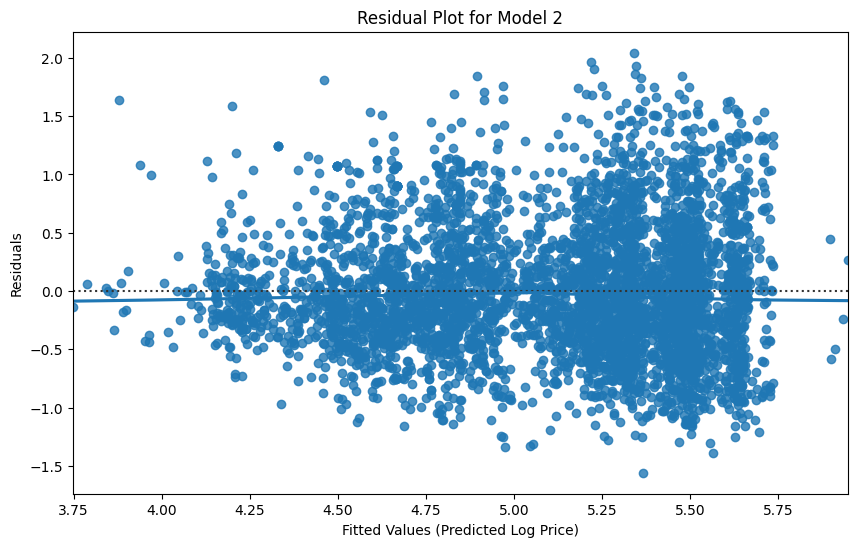

In [ ]:
# Create residual plot
plt.figure(figsize=(10, 6))

# x: fitted values, y: residuals
sns.residplot(
    x=model2.fittedvalues,
    y=model2.resid,
    lowess=True
)

# Add labels and title
plt.xlabel("Fitted Values (Predicted Log Price)")
plt.ylabel("Residuals")
plt.title("Residual Plot for Model 2")

# Show plot
plt.show()
